# 02. Train/Test Drift 분석

**핵심 문제**: Train(9기)와 Test(10기)의 분포가 다른가?

**방법**: L1 Distance 계산

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

warnings.filterwarnings(action='ignore')
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
	plt.rcParams['font.family'] = 'AppleGothic'
plt.rc('axes', unicode_minus=False)

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f"Train: {train.shape} (9기)")
print(f"Test: {test.shape} (10기)")

Train: (748, 46) (9기)
Test: (814, 45) (10기)


## 1. L1 Distance란?

두 확률 분포의 차이를 측정하는 지표

$$L1 = \sum_{i} |P_{train}(x_i) - P_{test}(x_i)|$$

**해석**:
- 0.0 ~ 0.1: 매우 안정 (거의 동일)
- 0.1 ~ 0.2: 안정 (사용 가능)
- 0.2 ~ 0.5: 보통 (주의 필요)
- 0.5 이상: 높음 (사용 불가)

In [3]:
def calculate_l1_distance(train_col, test_col):
    """
    L1 Distance 계산
    """
    # 확률 분포 계산
    train_dist = train_col.value_counts(normalize=True, dropna=False)
    test_dist = test_col.value_counts(normalize=True, dropna=False)
    
    # 모든 카테고리 합치기
    all_categories = set(train_dist.index) | set(test_dist.index)
    
    # L1 Distance
    l1 = 0
    for cat in all_categories:
        p_train = train_dist.get(cat, 0)
        p_test = test_dist.get(cat, 0)
        l1 += abs(p_train - p_test)
    
    return l1

## 2. 전체 변수 L1 Distance 계산

In [4]:
# 범주형 변수만
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col in test.columns and col != 'ID']

l1_results = []

for col in cat_cols:
    l1 = calculate_l1_distance(train[col], test[col])
    l1_results.append({
        'variable': col,
        'l1_distance': l1
    })

l1_df = pd.DataFrame(l1_results).sort_values('l1_distance', ascending=False)

print("L1 Distance 상위 20개 변수:")
print(l1_df.head(20))

L1 Distance 상위 20개 변수:
                           variable  l1_distance
1                          major1_1     1.946524
32                onedayclass_topic     1.911765
28  incumbents_lecture_scale_reason     1.788409
2                          major1_2     1.550369
19                      desired_job     1.284940
29               interested_company     1.177193
30                  expected_domain     0.899696
21              desired_certificate     0.846148
6                      inflow_route     0.428675
16                      major_field     0.421376
22          desired_job_except_data     0.413571
7                            whyBDA     0.412560
20          certificate_acquisition     0.322156
15                 previous_class_8     0.187094
0                        major type     0.122995
8                      what_to_gain     0.096546
26          incumbents_lecture_type     0.083321
27         incumbents_lecture_scale     0.081298
23                 incumbents_level     0.0805

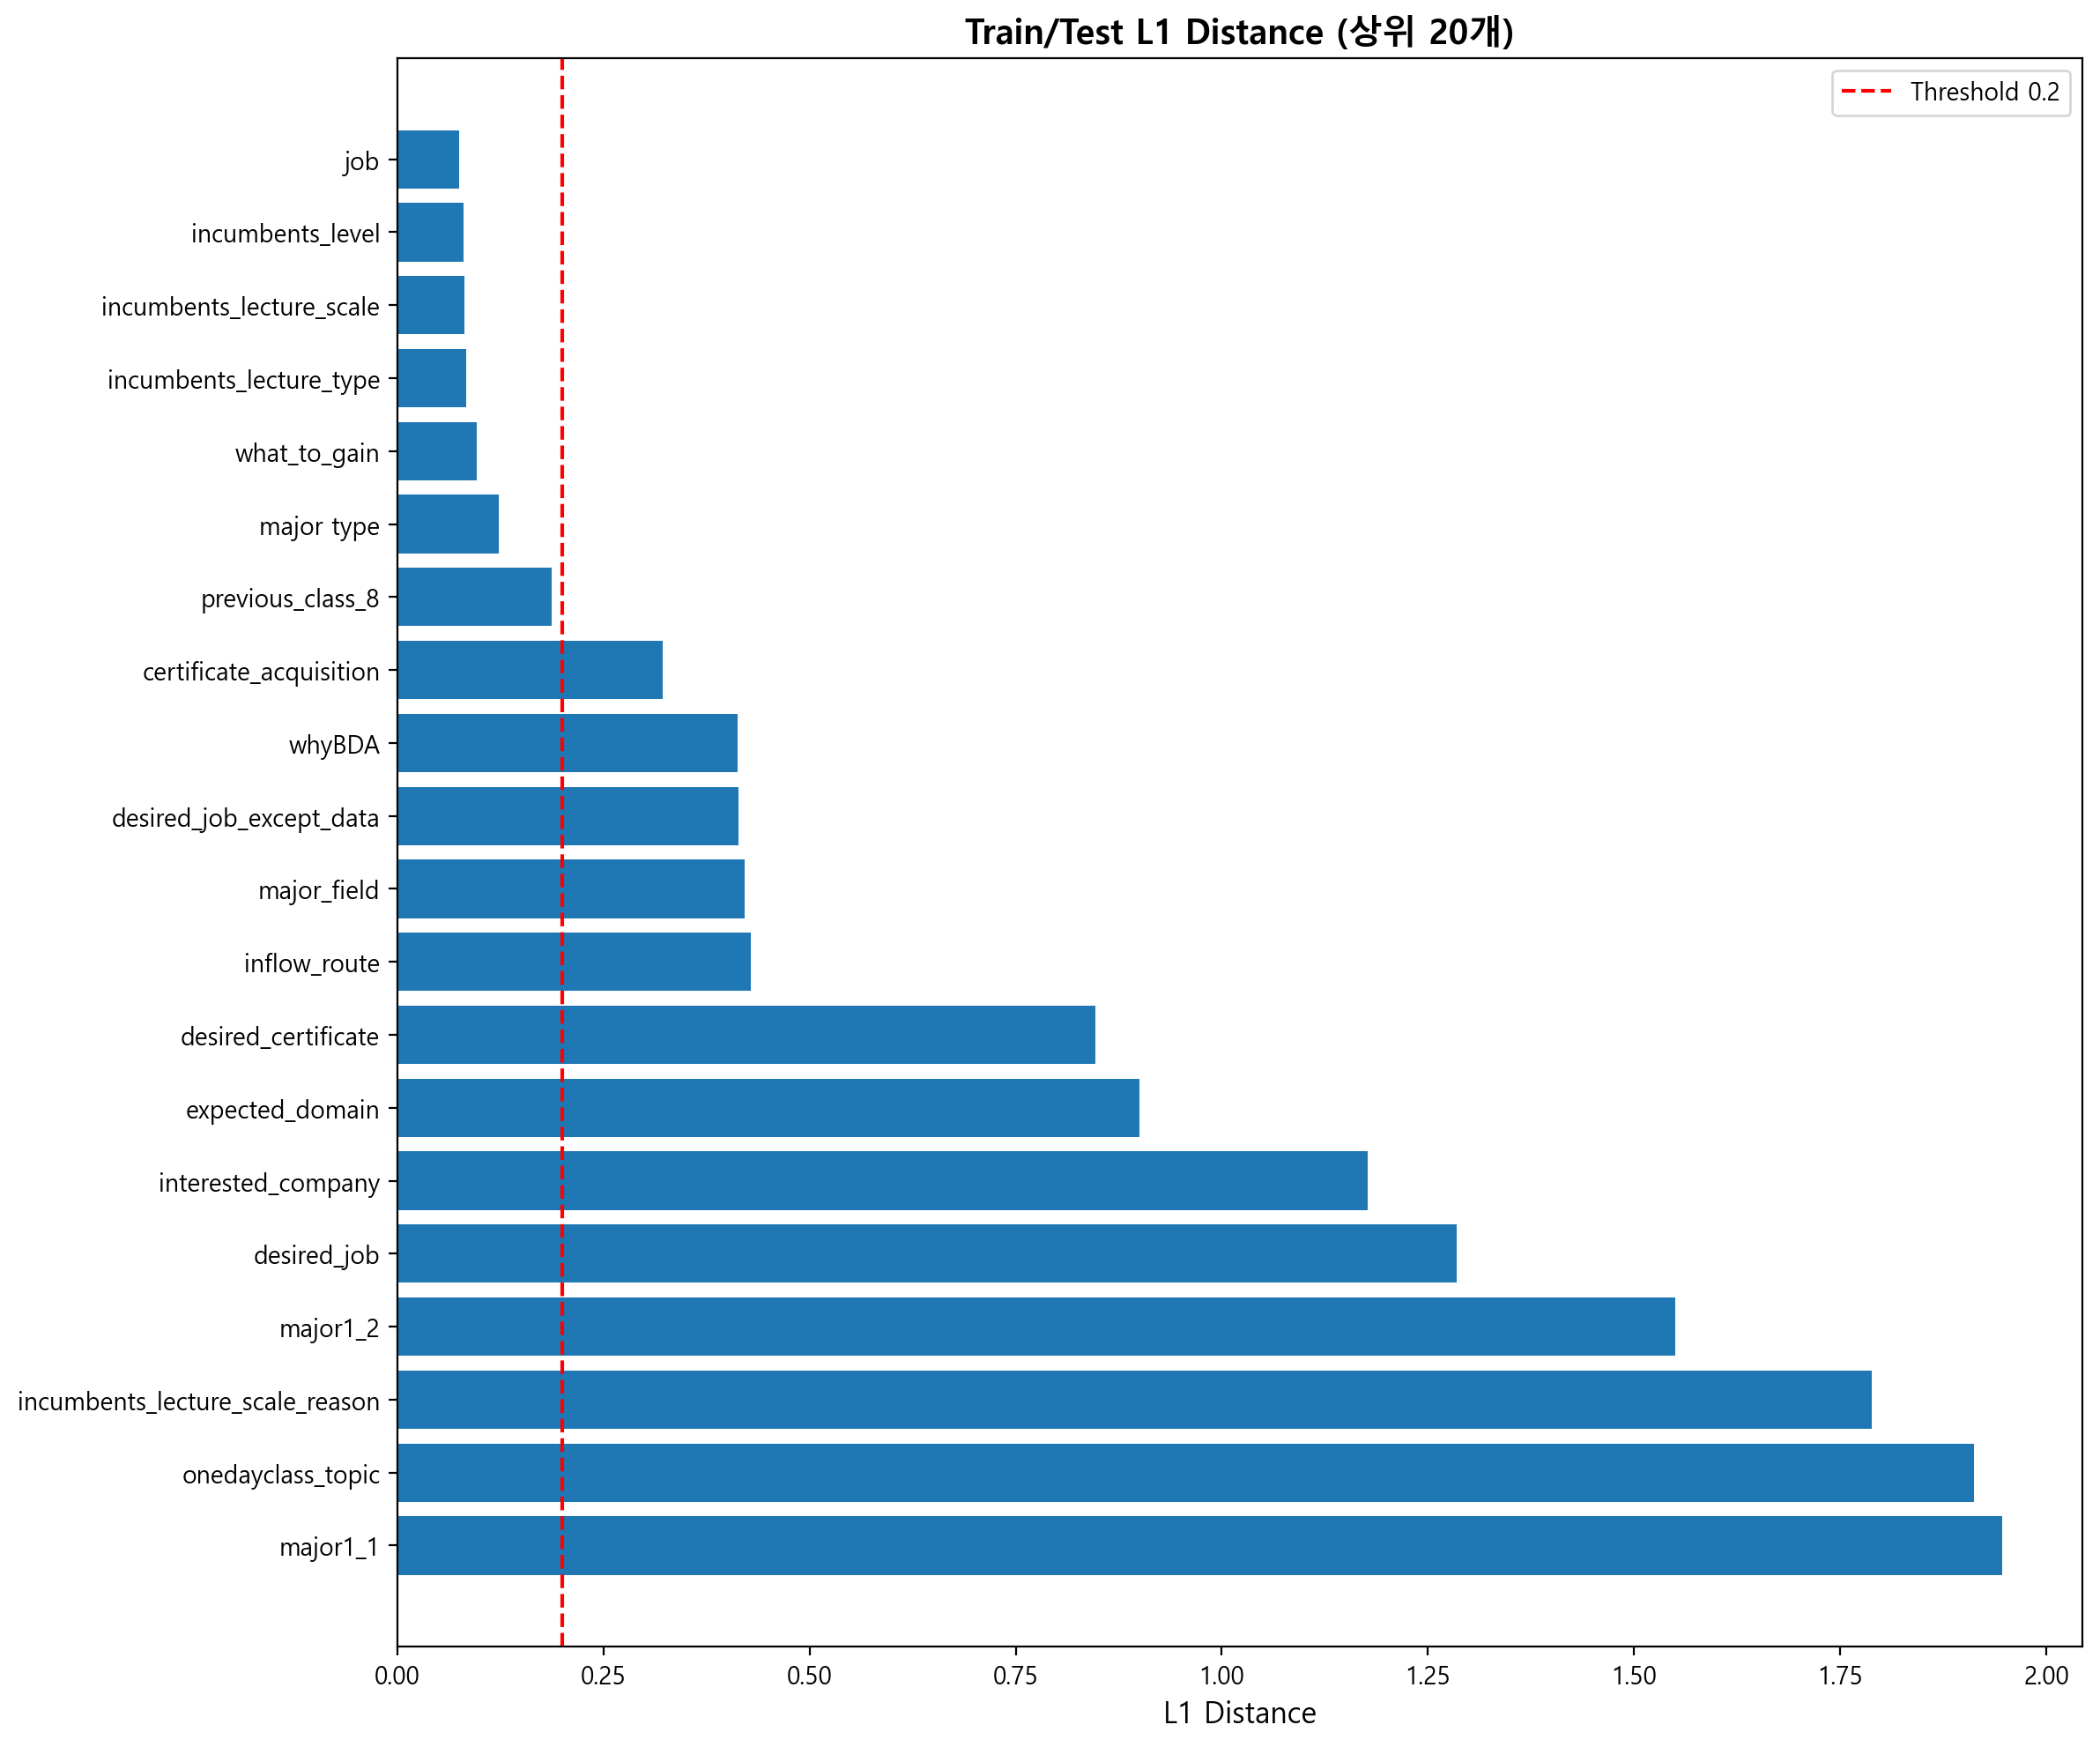

In [5]:
# 시각화
plt.figure(figsize=(12, 10))
plt.barh(range(len(l1_df.head(20))), l1_df.head(20)['l1_distance'])
plt.yticks(range(len(l1_df.head(20))), l1_df.head(20)['variable'])
plt.xlabel('L1 Distance', fontsize=12)
plt.title('Train/Test L1 Distance (상위 20개)', fontsize=14, fontweight='bold')
plt.axvline(x=0.2, color='r', linestyle='--', label='Threshold 0.2')
plt.legend()
plt.tight_layout()
plt.show()

## 3. 핵심 변수 상세 분석

In [6]:
# 텍스트 변수 (whyBDA)
if 'whyBDA' in cat_cols:
    l1_whyBDA = calculate_l1_distance(train['whyBDA'], test['whyBDA'])
    print(f"whyBDA L1 Distance: {l1_whyBDA:.3f}")
    
    # 상위 키워드
    train_keywords = train['whyBDA'].fillna('').str.split().explode().value_counts().head(10)
    test_keywords = test['whyBDA'].fillna('').str.split().explode().value_counts().head(10)
    
    print("\nTrain 상위 키워드:")
    print(train_keywords)
    
    print("\nTest 상위 키워드:")
    print(test_keywords)

whyBDA L1 Distance: 0.413

Train 상위 키워드:
whyBDA
공부하기    271
어려워서    271
혼자      271
잘       159
규모인     159
같아서     159
될것      159
큰       159
관리가     159
운영      159
Name: count, dtype: int64

Test 상위 키워드:
whyBDA
공부하기      377
혼자        377
어려워서      377
큰         165
규모인       165
등         165
관리가       165
잘         165
만큼,       164
커리큘럼이나    164
Name: count, dtype: int64


major1_1 L1 Distance: 1.947


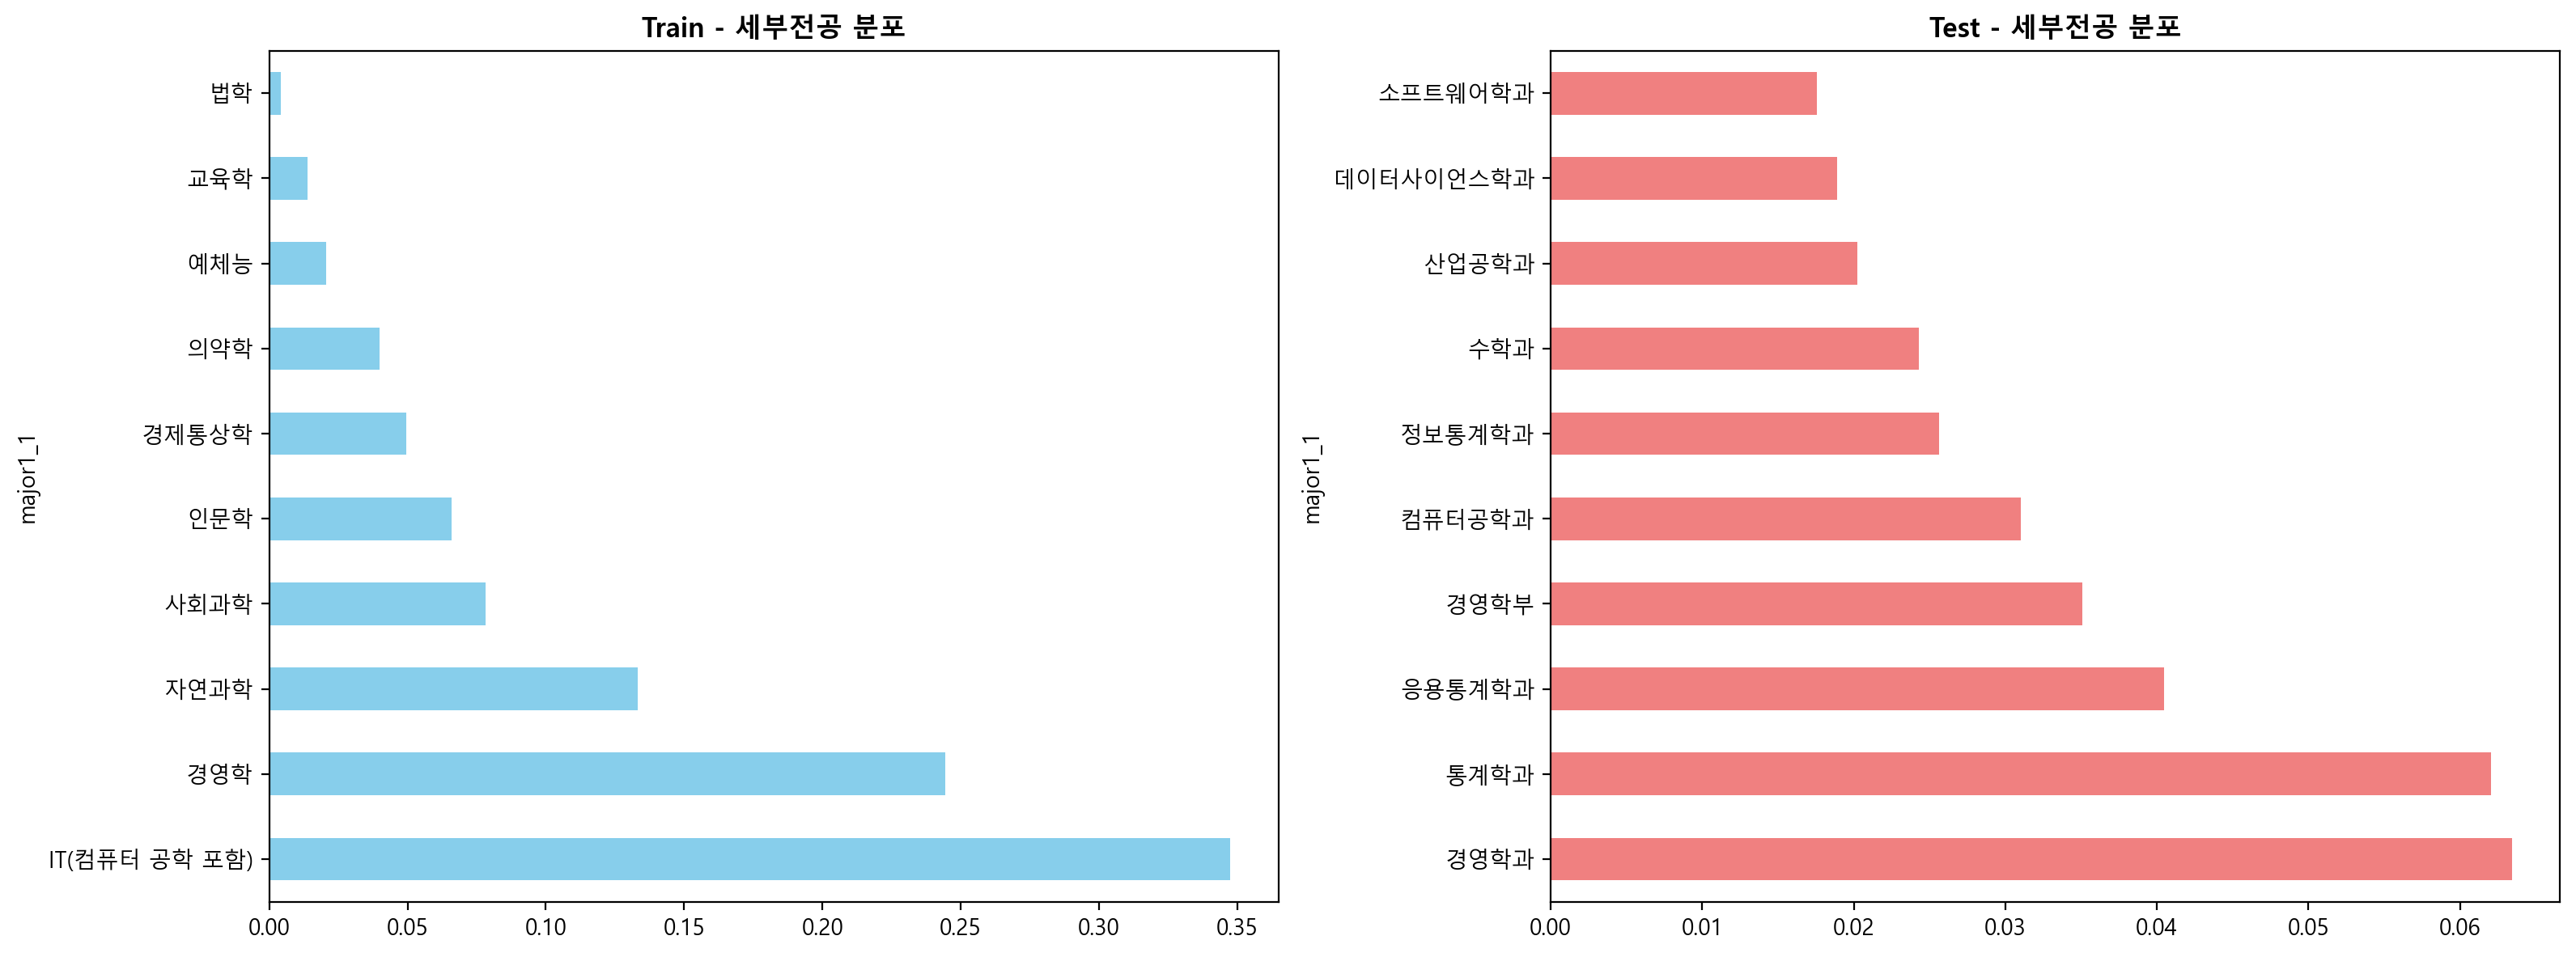

In [7]:
# 세부 전공 (major1_1)
if 'major1_1' in cat_cols:
    l1_major = calculate_l1_distance(train['major1_1'], test['major1_1'])
    print(f"major1_1 L1 Distance: {l1_major:.3f}")
    
    # Train vs Test 분포
    train_major = train['major1_1'].value_counts(normalize=True).head(10)
    test_major = test['major1_1'].value_counts(normalize=True).head(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    train_major.plot(kind='barh', ax=axes[0], color='skyblue')
    axes[0].set_title('Train - 세부전공 분포', fontsize=12, fontweight='bold')
    
    test_major.plot(kind='barh', ax=axes[1], color='lightcoral')
    axes[1].set_title('Test - 세부전공 분포', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 4. 안정 변수 찾기 (L1 < 0.2)

In [8]:
# 안정 변수
stable_vars = l1_df[l1_df['l1_distance'] < 0.2]

print(f"안정 변수 개수: {len(stable_vars)} / {len(l1_df)}")
print("\n안정 변수 목록:")
print(stable_vars)

안정 변수 개수: 20 / 33

안정 변수 목록:
                    variable  l1_distance
15          previous_class_8     0.187094
0                 major type     0.122995
8               what_to_gain     0.096546
26   incumbents_lecture_type     0.083321
27  incumbents_lecture_scale     0.081298
23          incumbents_level     0.080503
3                        job     0.074722
9             hope_for_group     0.072771
17       desired_career_path     0.055716
24        incumbents_lecture     0.052826
25  incumbents_company_level     0.049429
14          previous_class_7     0.027966
31     contest_participation     0.024064
12          previous_class_5     0.018717
13          previous_class_6     0.018428
11          previous_class_4     0.014236
4            re_registration     0.009539
10          previous_class_3     0.009539
18              project_type     0.006143
5                nationality     0.004480


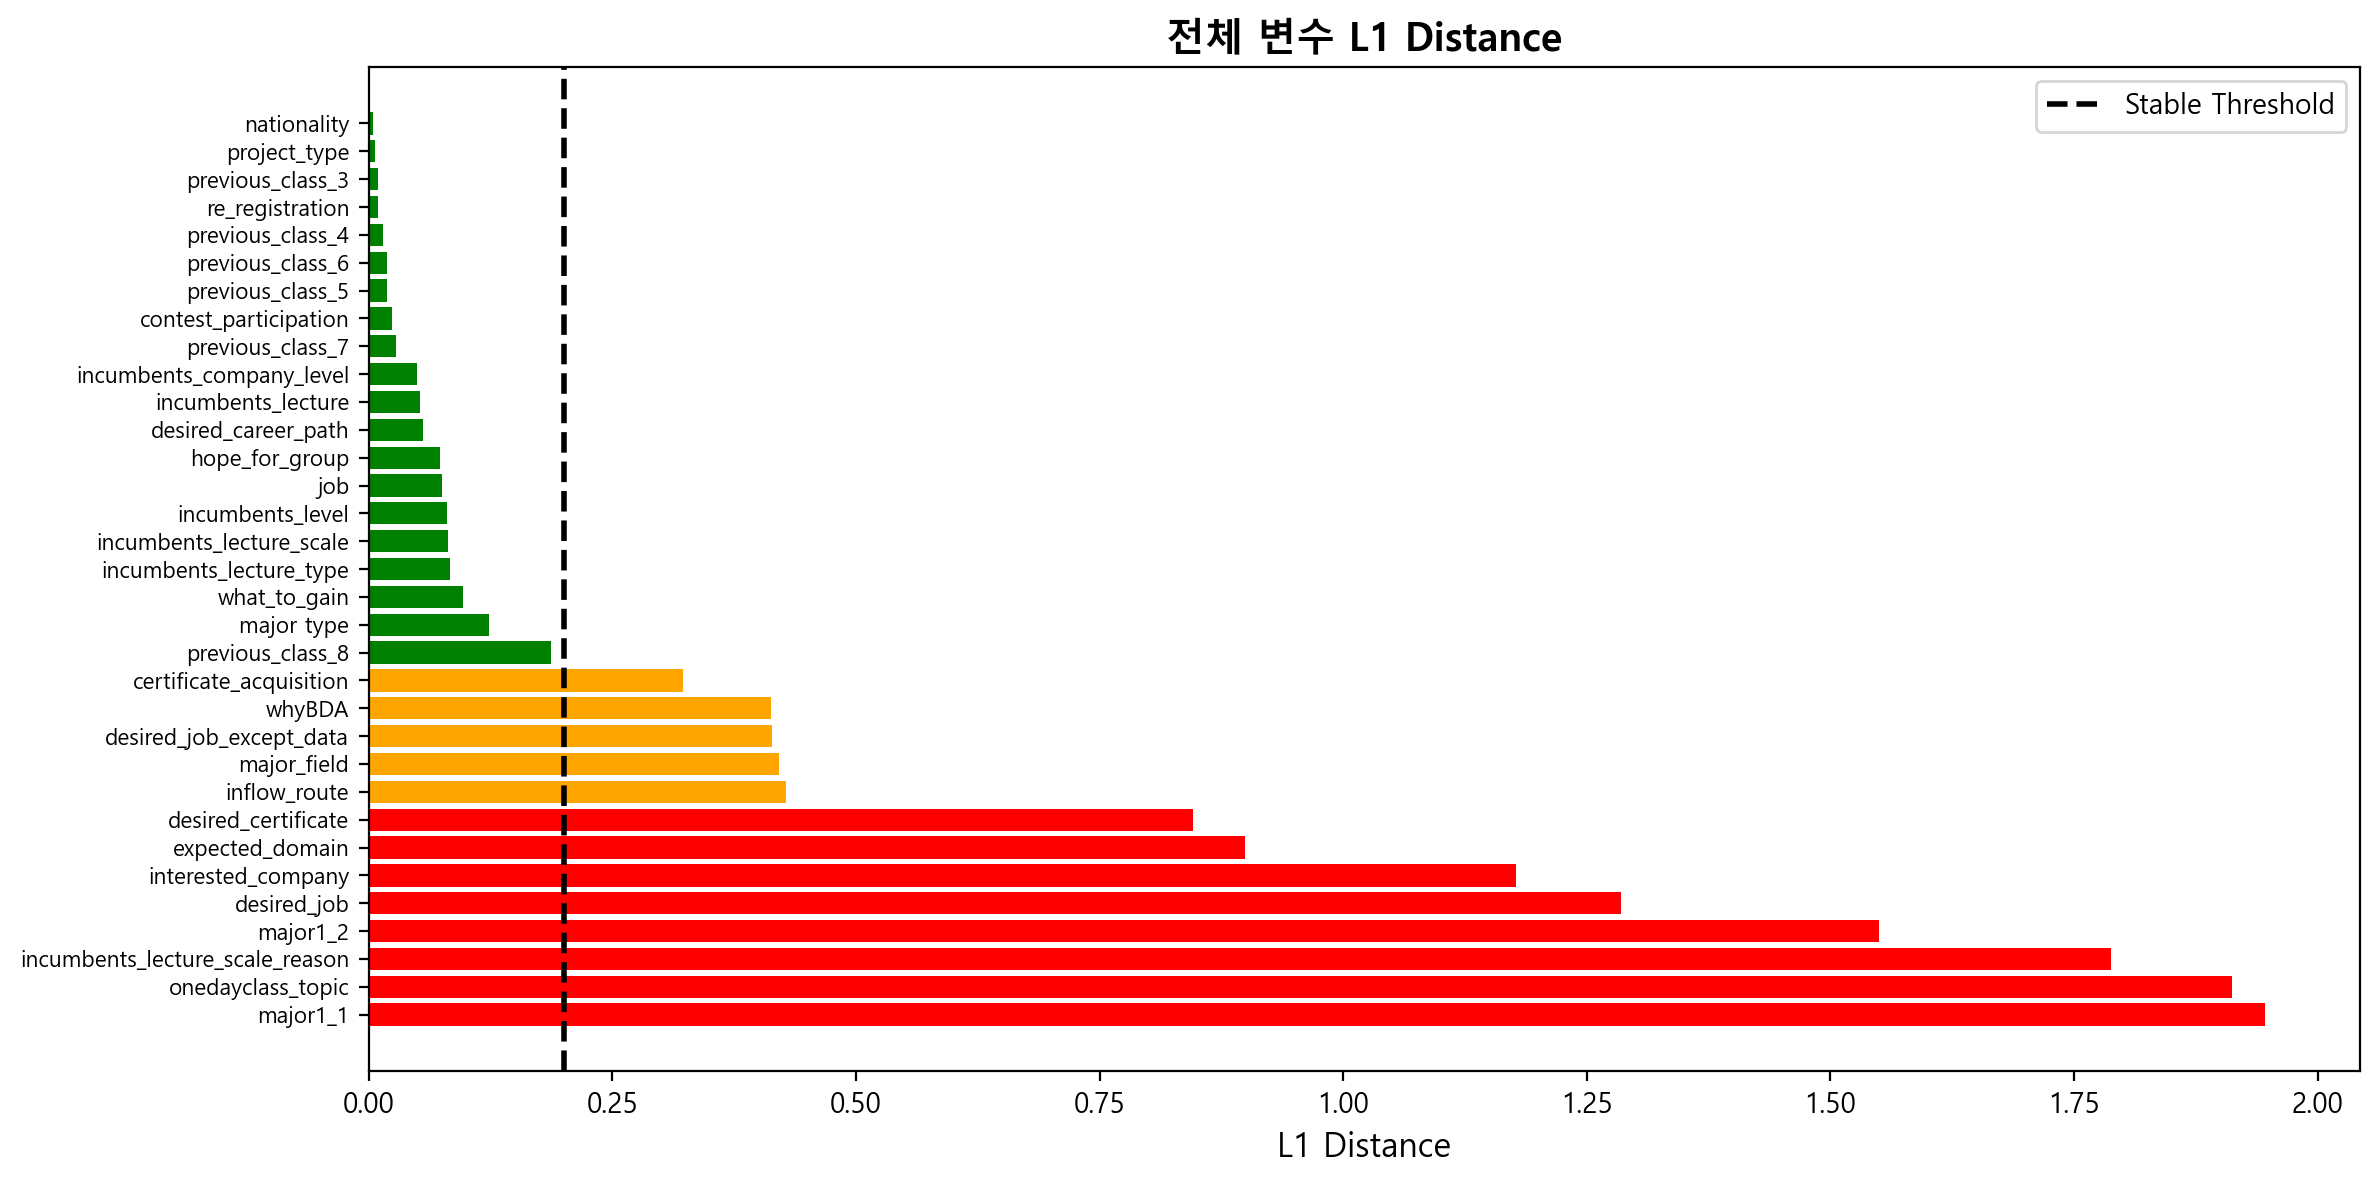

In [9]:
# 시각화
plt.figure(figsize=(12, 6))
colors = ['green' if x < 0.2 else 'orange' if x < 0.5 else 'red' for x in l1_df['l1_distance']]
plt.barh(range(len(l1_df)), l1_df['l1_distance'], color=colors)
plt.yticks(range(len(l1_df)), l1_df['variable'], fontsize=8)
plt.xlabel('L1 Distance', fontsize=12)
plt.title('전체 변수 L1 Distance', fontsize=14, fontweight='bold')
plt.axvline(x=0.2, color='black', linestyle='--', linewidth=2, label='Stable Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 5. 수치형 변수 분석

In [10]:
# 재등록
train_re = train['re_registration'].value_counts(normalize=True)
test_re = test['re_registration'].value_counts(normalize=True)

l1_re = calculate_l1_distance(train['re_registration'], test['re_registration'])

print(f"재등록 L1 Distance: {l1_re:.3f}")
print("\nTrain:")
print(train_re)
print("\nTest:")
print(test_re)

재등록 L1 Distance: 0.010

Train:
re_registration
아니요    0.804813
예      0.195187
Name: proportion, dtype: float64

Test:
re_registration
아니요    0.809582
예      0.190418
Name: proportion, dtype: float64


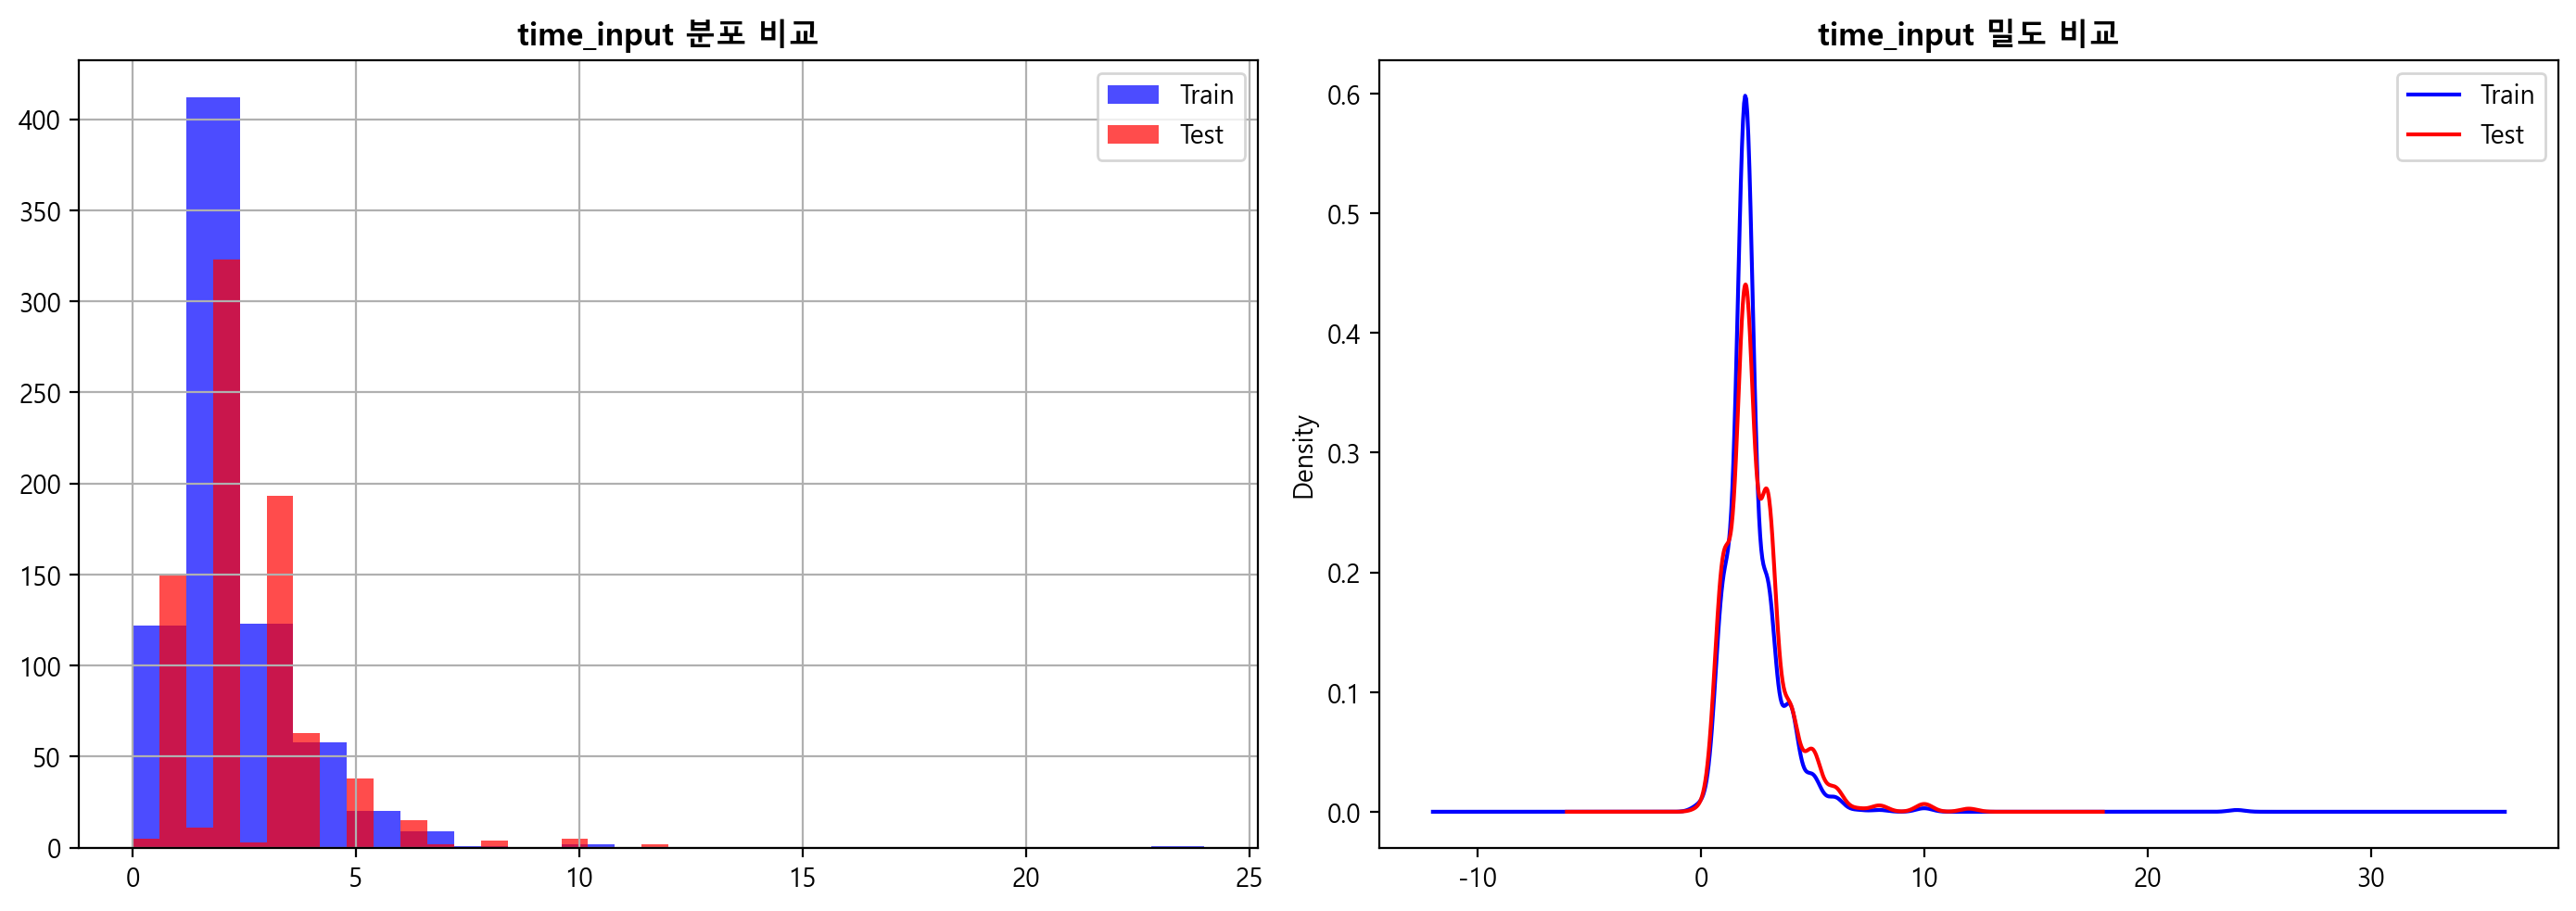

Train time_input 평균: 2.3264705882352943
Test time_input 평균: 2.5212530712530716
차이: 0.19478248301777734


In [11]:
# 시간 투입
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['time_input'].hist(bins=20, ax=axes[0], alpha=0.7, label='Train', color='blue')
test['time_input'].hist(bins=20, ax=axes[0], alpha=0.7, label='Test', color='red')
axes[0].set_title('time_input 분포 비교', fontsize=12, fontweight='bold')
axes[0].legend()

# KDE
train['time_input'].plot(kind='kde', ax=axes[1], label='Train', color='blue')
test['time_input'].plot(kind='kde', ax=axes[1], label='Test', color='red')
axes[1].set_title('time_input 밀도 비교', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# 통계
print("Train time_input 평균:", train['time_input'].mean())
print("Test time_input 평균:", test['time_input'].mean())
print("차이:", abs(train['time_input'].mean() - test['time_input'].mean()))

## 6. 주요 발견사항

### 사용 불가 변수 (L1 > 0.5)
- **major1_1** (세부전공): L1 = 1.947
- **onedayclass_topic**: L1 = 1.912
- **incumbents_lecture_scale_reason**: L1 = 1.788
- **major1_2** (제2전공): L1 = 1.550
- **desired_job**: L1 = 1.285
- **interested_company**: L1 = 1.177

→ **9기와 10기의 세부전공, 설문 텍스트가 완전히 다름**  
→ `school1`은 숫자형으로 범주형 L1 분석에서 제외됨

### 주의 변수 (L1 0.2 ~ 0.5)
- **major_field** (대분류): L1 = 0.421 — Lift 유의미한 일부 카테고리만 사용
- **whyBDA**: L1 = 0.413 — 일부 공통 패턴("혼자 공부하기 어려워서") 존재
- **inflow_route**: L1 = 0.429

### 안정 변수 (L1 < 0.2)
- **re_registration**: L1 = 0.010 (가장 신뢰)
- **job**: L1 = 0.075
- **what_to_gain**: L1 = 0.097
- **incumbents_lecture_type**: L1 = 0.083
- **time_input**: 연속형, 분포 유사

→ **이 변수들만 안정적으로 사용 가능**

### 전략
1. L1 < 0.2 변수를 우선 사용
2. major_field는 Lift 검증된 카테고리만 조건부 사용
3. 세부 범주(major1_1 등) 사용 불가

### 다음 단계
- Lift 분석으로 통계 검증 (03_lift_analysis.ipynb)